In [2]:
import pandas as pd
import numpy as np
import csv
import json
import pandas as pd
import seaborn as sns


In [3]:
#Exploratory Data Analysis
df = pd.read_csv('C:/Users/Premr/Downloads/Online_Retail.csv',encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.0,France


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Task 1
1.Are there any countries where there is a significantly higher or lower customer acquisition cost, and can that identify the reasons behind these variations?

In [6]:
import pandas as pd

# 1. Prep Data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 2. Find the first invoice for each customer
first_invoices = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_invoices.columns = ['CustomerID', 'FirstInvoiceDate']

# 3. Merge and Filter for "Acquisition" transactions
df = df.merge(first_invoices, on='CustomerID')
new_cust_df = df[df['InvoiceDate'] == df['FirstInvoiceDate']]

# 4. Analyze by Country
country_analysis = new_cust_df.groupby('Country').agg({
    'CustomerID': 'nunique',
    'TotalSpend': 'sum',
    'Quantity': 'mean',
    'UnitPrice': 'mean'
}).rename(columns={'CustomerID': 'New_Customers', 'TotalSpend': 'Acquisition_Revenue'})

# 5. Calculate Revenue per New Customer (Your Proxy for CAC value)
country_analysis['Rev_Per_New_Cust'] = country_analysis['Acquisition_Revenue'] / country_analysis['New_Customers']
print(country_analysis.sort_values(by='Rev_Per_New_Cust', ascending=False).head(10))

             New_Customers  Acquisition_Revenue   Quantity  UnitPrice  \
Country                                                                 
Singapore                1              2053.07  19.482143   4.702500   
Lebanon                  1              1693.88   8.577778   5.387556   
Israel                   4              5547.80  15.171946   3.794977   
Japan                    8             11026.92  63.913793   1.857241   
Norway                  10             13299.42  18.315927   3.987598   
Lithuania                1              1145.06  17.680000   2.943600   
Brazil                   1              1143.60  11.125000   4.456250   
Greece                   4              4339.28  10.851240   4.696364   
Denmark                  8              8605.21  19.732143   3.639643   
Switzerland             20             21480.36  14.927591   3.251785   

             Rev_Per_New_Cust  
Country                        
Singapore          2053.07000  
Lebanon            1693.880

# TASK 1

2.What are the revenue trends for the products in different countries, and which countries are contributing the most to the overall revenue

--- Top 5 Countries by Revenue Contribution ---
                Total Revenue  Contribution %
Country                                      
United Kingdom    6767873.394       81.539997
Netherlands        284661.540        3.429630
EIRE               250285.220        3.015461
Germany            221698.210        2.671042
France             196712.840        2.370015


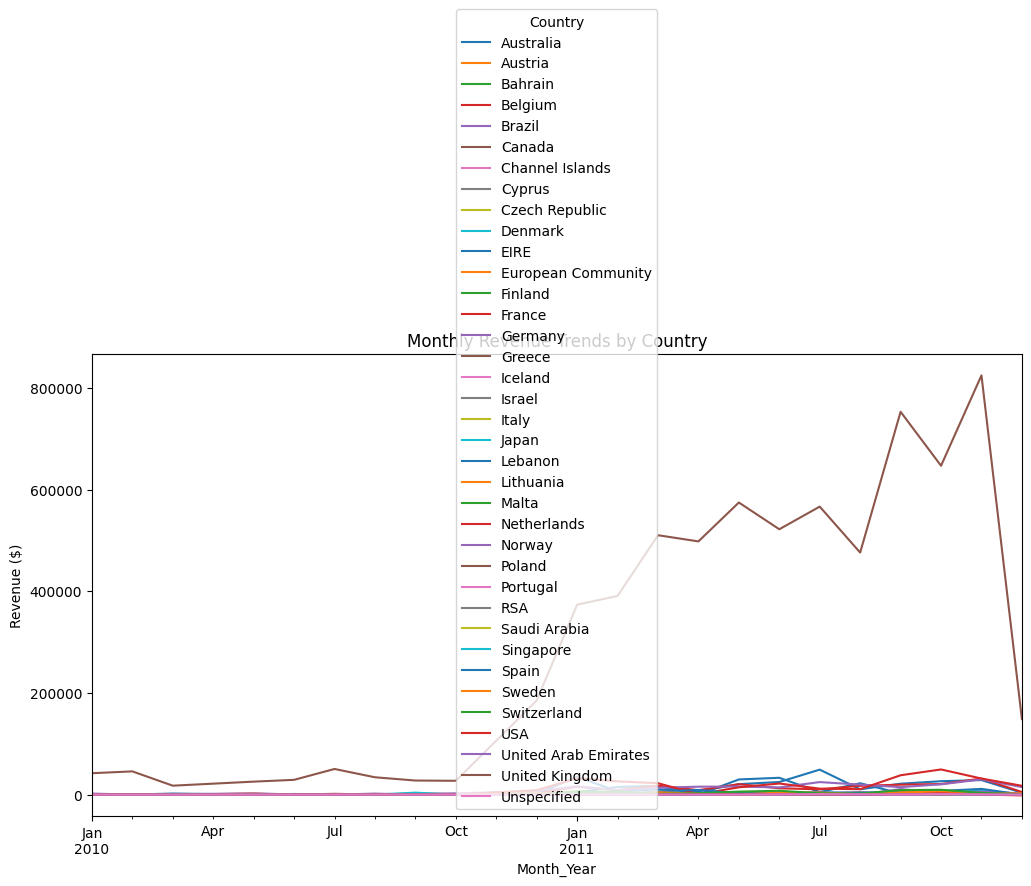

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Preparation
# Convert date to datetime and create Revenue column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract Month and Year for trend analysis
df['Month_Year'] = df['InvoiceDate'].dt.to_period('M')

# 2. Top Contributing Countries
# Sum revenue per country and calculate percentage of total
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
total_overall_revenue = country_revenue.sum()
country_contribution_pct = (country_revenue / total_overall_revenue) * 100

# 3. Revenue Trends by Country
# Pivot data to see monthly revenue for each country
monthly_trends = df.groupby(['Month_Year', 'Country'])['Revenue'].sum().unstack().fillna(0)

# Display results
print("--- Top 5 Countries by Revenue Contribution ---")
print(pd.DataFrame({
    'Total Revenue': country_revenue, 
    'Contribution %': country_contribution_pct
}).head(5))

# Plotting the Trend
monthly_trends.plot(kind='line', figsize=(12, 6))
plt.title('Monthly Revenue Trends by Country')
plt.ylabel('Revenue ($)')
plt.show()

# TASK 2
1.Which countries have the highest customer acquisition costs?

In [35]:
# Mature markets (High CAC) usually require higher spend %
spend_ratios = {
    'United Kingdom': 0.12, # 12% for mature, competitive market
    'Germany': 0.10,        # 10%
    'France': 0.10,
    'USA': 0.15,            # Highest competition usually
    'Brazil': 0.07,         # Emerging market often has lower entry costs
}

# Default ratio for any country not listed above
default_ratio = 0.08

# 2. Apply to your existing 'cac_proxy' table
def estimate_spend(row):
    ratio = spend_ratios.get(row.name, default_ratio)
    return row['Acquisition_Revenue'] * ratio

country_analysis['Est_Total_Spend'] = country_analysis.apply(estimate_spend, axis=1)

# 3. Final CAC Calculation
country_analysis['Estimated_CAC'] = country_analysis['Est_Total_Spend'] / country_analysis['New_Customers']

print(country_analysis[['New_Customers', 'Estimated_CAC', 'Acquisition_Revenue']].sort_values(by='Estimated_CAC', ascending=False))

                      New_Customers  Estimated_CAC  Acquisition_Revenue
Country                                                                
Singapore                         1     164.245600             2053.070
Lebanon                           1     135.510400             1693.880
Israel                            4     110.956000             5547.800
Japan                             8     110.269200            11026.920
USA                               4     106.826250             2848.700
Norway                           10     106.395360            13299.420
Lithuania                         1      91.604800             1145.060
Greece                            4      86.785600             4339.280
Denmark                           8      86.052100             8605.210
Switzerland                      20      85.921440            21480.360
RSA                               1      80.184800             1002.310
Brazil                            1      80.052000             1

2.Can you provide insights into customer preferences or product popularity by country, and how can that help to tailor marketing campaigns to these preferences?

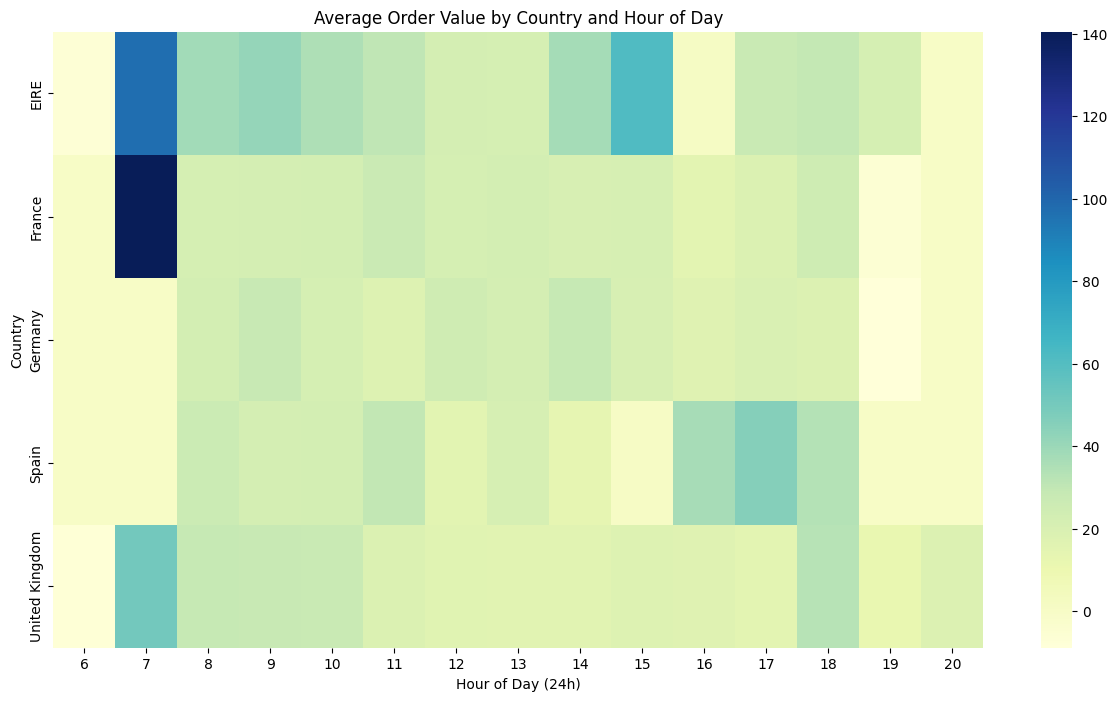

In [37]:
import seaborn as sns

# 1. Extract Hour and identify top countries
df['Hour'] = df['InvoiceDate'].dt.hour
top_5_countries = df['Country'].value_counts().head(5).index
subset = df[df['Country'].isin(top_5_countries)]

# 2. Create a Pivot Table for the Heatmap
# We use 'mean' revenue to see the "typical" order value at that time
pivot_table = subset.pivot_table(index='Country', columns='Hour', values='Revenue', aggfunc='mean').fillna(0)

# 3. Visualize
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, annot=False, cmap='YlGnBu')
plt.title('Average Order Value by Country and Hour of Day')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Country')
plt.show()

# TASK 3
What patterns or trends can you identify in the order dates over time? Are there specific months or seasons when orders tend to spike or drop? How might this affect the overall business strategy or resource allocation?

Average Unit Price: $3.46
Median Unit Price: $1.95

--- Top 5 Highest Priced Products ---
       Description  UnitPrice
330871      Manual   38970.00
5025       POSTAGE    8142.75
5027        Manual    6930.00
343872      Manual    4287.63
383957      Manual    4161.06


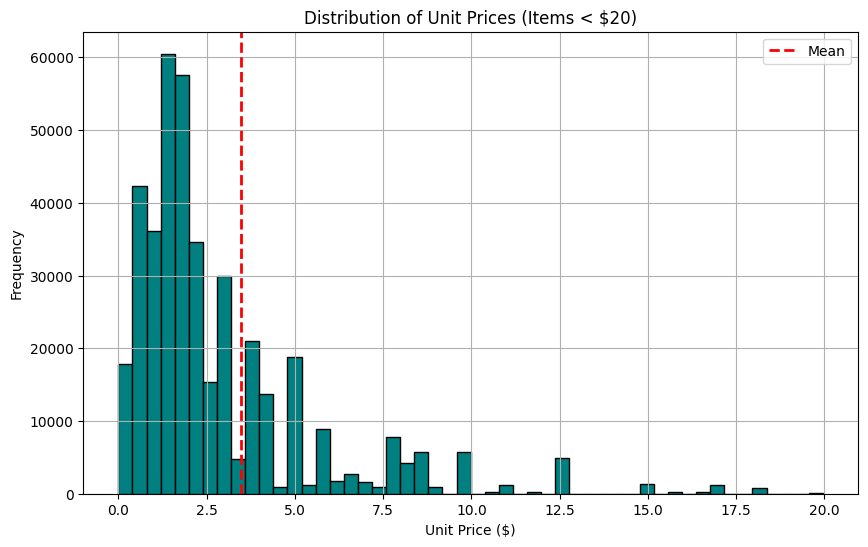

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Basic Unit Price Stats
avg_unit_price = df['UnitPrice'].mean()
median_unit_price = df['UnitPrice'].median()

print(f"Average Unit Price: ${avg_unit_price:.2f}")
print(f"Median Unit Price: ${median_unit_price:.2f}")

# 2. Identify High-Price & Low-Price Outliers
# We define outliers as anything 3 standard deviations away from the mean
std_dev = df['UnitPrice'].std()
high_price_threshold = avg_unit_price + (3 * std_dev)

high_value_products = df[df['UnitPrice'] > high_price_threshold][['Description', 'UnitPrice']].drop_duplicates()
low_value_products = df[df['UnitPrice'] < 1.0][['Description', 'UnitPrice']].drop_duplicates()

print("\n--- Top 5 Highest Priced Products ---")
print(high_value_products.sort_values(by='UnitPrice', ascending=False).head(5))

# 3. Visualize the Distribution
plt.figure(figsize=(10, 6))
df[df['UnitPrice'] < 20]['UnitPrice'].hist(bins=50, color='teal', edgecolor='black')
plt.axvline(avg_unit_price, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribution of Unit Prices (Items < $20)')
plt.xlabel('Unit Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# TASK 4
 Do changes in unit prices have a noticeable impact on customer buying behavior? Are customers more likely to purchase in larger quantities when prices are lower, or are they willing to pay a premium for certain products?

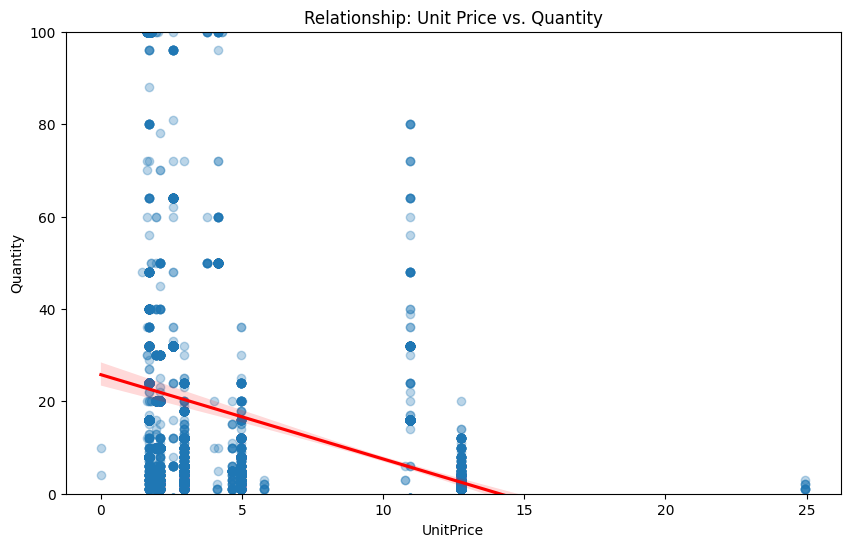

Correlation per Product (Negative = Price Sensitive):
WHITE HANGING HEART T-LIGHT HOLDER: -0.11
REGENCY CAKESTAND 3 TIER: -0.29
JUMBO BAG RED RETROSPOT: -0.40
ASSORTED COLOUR BIRD ORNAMENT: -0.48
PARTY BUNTING: -0.48


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for Top 5 Products (to avoid noise)
top_products = df['Description'].value_counts().head(5).index
product_data = df[df['Description'].isin(top_products)]

# 2. Calculate Correlation for each product
correlations = {}
for product in top_products:
    item_df = product_data[product_data['Description'] == product]
    # Correlation between Price and Quantity
    corr = item_df['UnitPrice'].corr(item_df['Quantity'])
    correlations[product] = corr

# 3. Visualize the Relationship with a Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=product_data, x='UnitPrice', y='Quantity', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship: Unit Price vs. Quantity')
plt.ylim(0, 100) # Limit Y to see the bulk of data clearly
plt.show()

print("Correlation per Product (Negative = Price Sensitive):")
for prod, val in correlations.items():
    print(f"{prod}: {val:.2f}")

# TASK 5
 How can we use Customer IDs to segment the customer base effectively, and which segments are currently the most profitable for the business?

In [40]:
import pandas as pd
import datetime as dt

# 1. Prepare Data
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Calculate RFM Metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalRevenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 3. Assign Scoring (1-4 scale, 4 is best)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# 4. Define Segments
def segment_me(df):
    if df['R_score'] == 4 and df['M_score'] == 4:
        return 'Champions (Best)'
    elif df['M_score'] == 4:
        return 'Big Spenders'
    elif df['R_score'] == 1:
        return 'Lost Customers'
    else:
        return 'Regulars'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

# 5. Check Profitability
segment_stats = rfm.groupby('Segment').agg({
    'Monetary': ['mean', 'sum'],
    'Recency': 'mean'
}).round(1)

print(segment_stats)

                 Monetary            Recency
                     mean        sum    mean
Segment                                     
Big Spenders       4088.0  2309713.0    69.2
Champions (Best)   7974.1  4210301.6    10.2
Lost Customers      355.5   371871.7   266.7
Regulars            630.6  1408179.6    54.7


# TASK 6
Are there specific customer segments, identified by Customer IDs, that engage more with the marketing campaigns, and how can it help to tailor the marketing strategies to better target them?

In [41]:
# Assuming you have an 'rfm' dataframe from the previous step
# 1. Define engagement tiers based on Frequency and Recency
def engagement_tier(row):
    if row['F_score'] >= 4 and row['R_score'] >= 4:
        return 'High Engagement'
    elif row['R_score'] <= 1:
        return 'Lapsed/Low Engagement'
    else:
        return 'Standard'

rfm['Engagement_Level'] = rfm.apply(engagement_tier, axis=1)

# 2. Check the average Monetary value for High Engagement vs others
engagement_impact = rfm.groupby('Engagement_Level')['Monetary'].mean()
print(engagement_impact)

Engagement_Level
High Engagement          7205.983843
Lapsed/Low Engagement     440.201359
Standard                 1357.919433
Name: Monetary, dtype: float64
